In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [4]:
df = pd.read_excel("Flight_Fare.xlsx")

In [5]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [6]:
df.shape

(10683, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [8]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [11]:
df["Journey_day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day

df["Journey_month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month

In [12]:
df.drop("Date_of_Journey", axis=1, inplace=True)

In [13]:
df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour

df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

/tmp/ipykernel_8079/1566029390.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
/tmp/ipykernel_8079/1566029390.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute


In [15]:
df.drop("Dep_Time", axis=1, inplace=True)

In [16]:
df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour

df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

/tmp/ipykernel_8079/3059177722.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
/tmp/ipykernel_8079/3059177722.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute


In [17]:
df.drop("Arrival_Time", axis=1, inplace=True)

In [18]:
duration = list(df["Duration"])

duration_hours = []
duration_mins = []

for i in duration:

    if len(i.split()) != 2:

        if "h" in i:
            i = i.strip() + " 0m"

        else:
            i = "0h " + i

    hours = int(i.split(sep="h")[0])

    mins = int(i.split(sep="m")[0].split()[-1])

    duration_hours.append(hours)

    duration_mins.append(mins)

In [19]:
df["Duration_hours"] = duration_hours

df["Duration_mins"] = duration_mins

In [20]:
df.drop("Duration", axis=1, inplace=True)

In [21]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


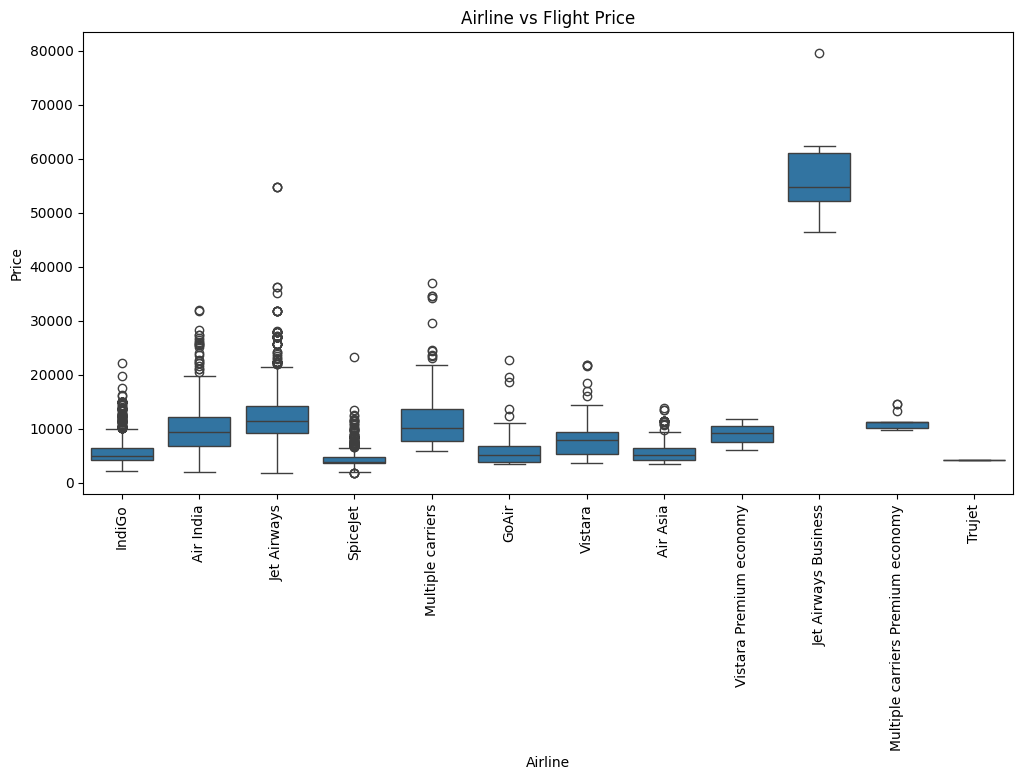

In [22]:
plt.figure(figsize=(12,6))

sns.boxplot(x='Airline', y='Price', data=df)

plt.xticks(rotation=90)

plt.title("Airline vs Flight Price")

plt.show()

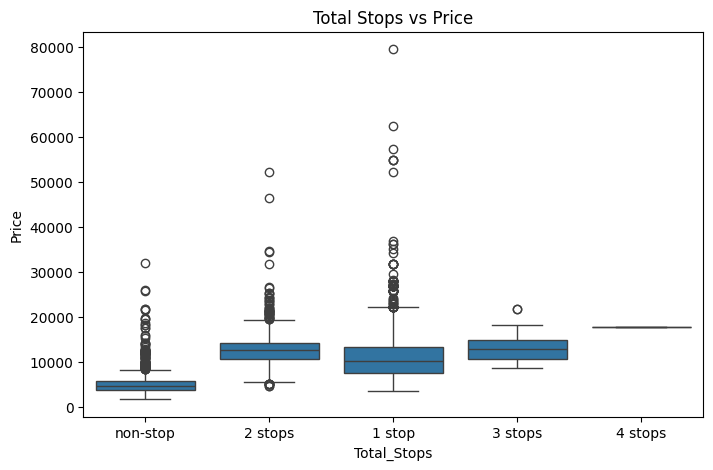

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Total_Stops', y='Price', data=df)

plt.title("Total Stops vs Price")

plt.show()

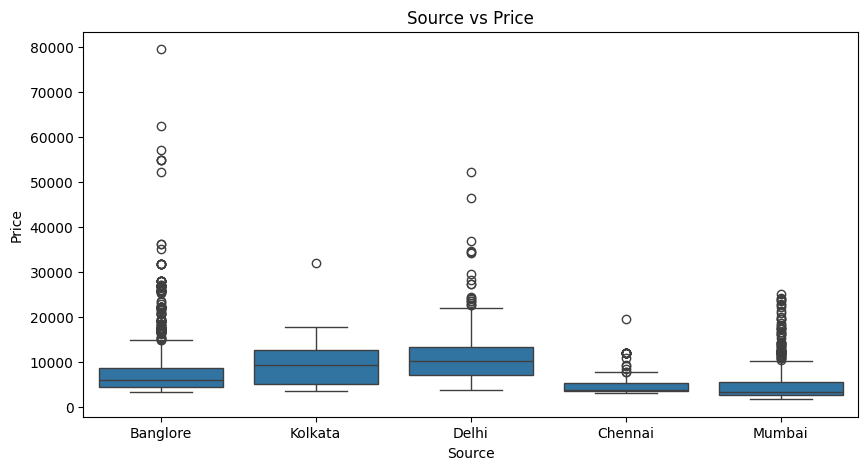

In [24]:
plt.figure(figsize=(10,5))

sns.boxplot(x='Source', y='Price', data=df)

plt.title("Source vs Price")

plt.show()

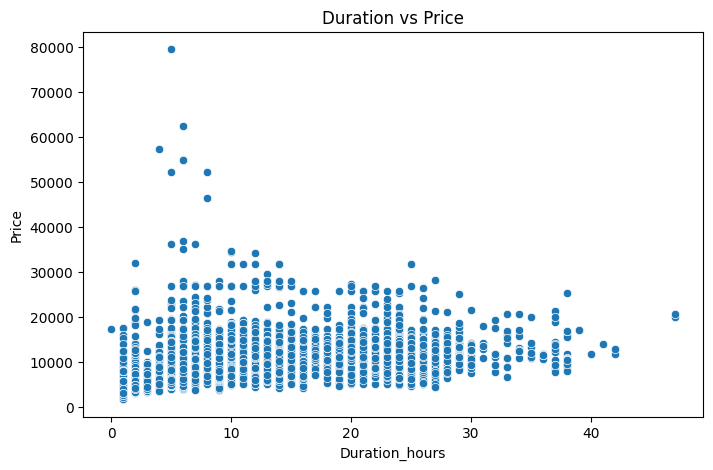

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Duration_hours', y='Price', data=df)

plt.title("Duration vs Price")

plt.show()

In [26]:
## Observations

# 1. Flights with more stops generally have higher ticket prices.

# 2. Certain airlines have significantly higher fare ranges compared to others.

# 3. Longer flight durations tend to increase overall ticket prices.

# 4. Flight prices vary depending on source and destination locations.

In [27]:
df = pd.get_dummies(df, drop_first=True)

In [28]:
df.head()

,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,Airline_Air India,...,Total_Stops_non-stop,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,3897,24,3,22,20,1,10,2,50,False,...,True,False,False,False,False,False,False,False,True,False
1,7662,1,5,5,50,13,15,7,25,True,...,False,False,False,False,False,False,False,False,True,False
2,13882,9,6,9,25,4,25,19,0,False,...,False,False,False,False,False,False,False,False,True,False
3,6218,12,5,18,5,23,30,5,25,False,...,False,False,False,False,False,False,False,False,True,False
4,13302,1,3,16,50,21,35,4,45,False,...,False,False,False,False,False,False,False,False,True,False


In [29]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

In [34]:
results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

    print(f"\n{name}")
    print("-" * 40)

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)


Linear Regression
----------------------------------------
MAE : 1533.0721638627872
RMSE: 2309.916199006831
R2 Score: 0.7525415588282678

Decision Tree
----------------------------------------
MAE : 643.0011698642958
RMSE: 1793.6624028819917
R2 Score: 0.850792300736768

Random Forest
----------------------------------------
MAE : 609.8850433703975
RMSE: 1611.4749302404996
R2 Score: 0.8795638314011975


In [35]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1533.072164,2309.916199,0.752542
1,Decision Tree,643.001170,1793.662403,0.850792
2,Random Forest,609.885043,1611.474930,0.879564


In [36]:
results_df.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest,609.885043,1611.474930,0.879564
1,Decision Tree,643.001170,1793.662403,0.850792
0,Linear Regression,1533.072164,2309.916199,0.752542


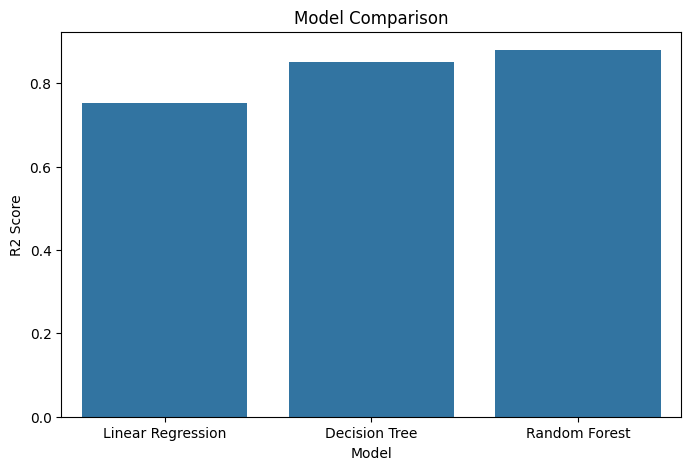

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="R2 Score", data=results_df)

plt.title("Model Comparison")

plt.show()

In [38]:
# ## Model Comparison Observation

# Different regression algorithms were trained and evaluated on the flight fare dataset. Random Forest Regressor achieved the best performance with a higher R2 Score and lower prediction error, making it suitable for production deployment.

In [39]:
# # Conclusion

# This project successfully analyzed flight fare data and developed regression-based machine learning models for price prediction. Feature engineering on time and duration columns significantly improved model performance.

# Among all models, Random Forest Regressor delivered the best prediction performance, demonstrating the effectiveness of machine learning in solving real-world airline pricing problems.

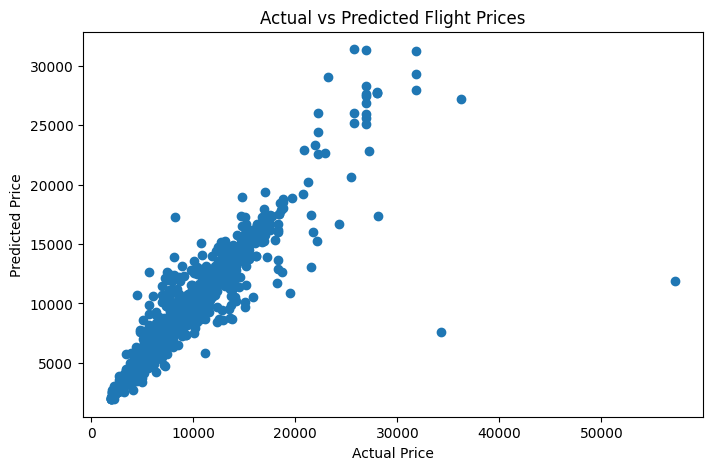

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Flight Prices")

plt.show()